# Welcome to Modal notebooks!

Write Python code and collaborate in real time. Your code runs in Modal's
**serverless cloud**, and anyone in the same workspace can join.

This notebook comes with some common Python libraries installed. Run
cells with `Shift+Enter`.

In [8]:
# %uv pip install -U accelerate datasets pillow sentencepiece safetensors pillow transformers --force-reinstall
# %uv pip install -U torch torchvision --index-url https://download.pytorch.org/whl/cu129
# %uv pip install --no-deps trl 

Using Python 3.12.6 environment at: /usr/local
Resolved 76 packages in 137ms
Prepared 76 packages in 7ms
Uninstalled 76 packages in 489ms
Installed 76 packages in 412ms
 ~ accelerate==1.13.0
 ~ aiohappyeyeballs==2.6.2
 ~ aiohttp==3.14.0
 ~ aiosignal==1.4.0
 ~ annotated-doc==0.0.4
 ~ anyio==4.13.0
 ~ attrs==26.1.0
 ~ certifi==2026.5.20
 ~ charset-normalizer==3.4.7
 ~ click==8.4.1
 ~ cuda-bindings==13.3.1
 ~ cuda-pathfinder==1.5.5
 ~ cuda-toolkit==13.0.2
 ~ datasets==4.8.5
 ~ dill==0.4.1
 ~ filelock==3.29.1
 ~ frozenlist==1.8.0
 - fsspec==2026.4.0
 + fsspec==2026.2.0
 ~ h11==0.16.0
 ~ hf-xet==1.5.0
 ~ httpcore==1.0.9
 ~ httpx==0.28.1
 ~ huggingface-hub==1.17.0
 ~ idna==3.18
 ~ jinja2==3.1.6
 ~ markdown-it-py==4.2.0
 ~ markupsafe==3.0.3
 ~ mdurl==0.1.2
 ~ mpmath==1.3.0
 ~ multidict==6.7.1
 ~ multiprocess==0.70.19
 ~ networkx==3.6.1
 ~ numpy==2.4.6
 ~ nvidia-cublas==13.1.1.3
 ~ nvidia-cuda-cupti==13.0.85
 ~ nvidia-cuda-nvrtc==13.0.88
 ~ nvidia-cuda-runtime==13.0.96
 ~ nvidia-cudnn-cu13==9.

In [1]:
%uv pip list

Using Python 3.12.6 environment at: /usr/local
Package                   Version
------------------------- ---------------
absl-py                   2.3.1
accelerate                1.13.0
aiofiles                  24.1.0
aiohappyeyeballs          2.6.2
aiohttp                   3.14.0
aiosignal                 1.4.0
altair                    5.5.0
annotated-doc             0.0.4
annotated-types           0.7.0
anthropic                 0.66.0
anyio                     4.13.0
asttokens                 3.0.0
asyncpg                   0.30.0
attrs                     26.1.0
authlib                   1.6.3
awscrt                    0.27.6
basedpyright              1.31.4
beautifulsoup4            4.13.5
bokeh                     3.8.0
boto3                     1.40.23
botocore                  1.40.23
cbor2                     6.1.2
certifi                   2026.5.20
cffi                      1.17.1
charset-normalizer        3.4.7
chex                      0.1.90
click                    

In [2]:
import torch
from datasets import load_dataset
from transformers import AutoProcessor, AutoModelForSeq2SeqLM
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, set_seed

In [3]:
set_seed(42)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)
print("bf16 supported:", torch.cuda.is_available() and torch.cuda.is_bf16_supported())

CUDA: True NVIDIA L40S
bf16 supported: True


In [5]:
DATASET_NAME = "full"
raw_train = load_dataset("linxy/LaTeX_OCR", name=DATASET_NAME, split="train")
raw_val   = load_dataset("linxy/LaTeX_OCR", name=DATASET_NAME, split="validation")

train_ds = raw_train.shuffle(seed=42).select(range(1000))
val_ds   = raw_val.shuffle(seed=42).select(range(200)) 

print(train_ds, val_ds)
print("Columns:", train_ds.column_names)

Dataset({
    features: ['image', 'text'],
    num_rows: 1000
}) Dataset({
    features: ['image', 'text'],
    num_rows: 200
})
Columns: ['image', 'text']


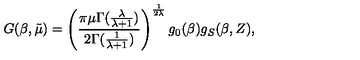

In [7]:
train_ds[10]["image"]

In [8]:
train_ds[10]["text"]

'G ( \\beta , \\tilde { \\mu } ) = \\left( \\frac { \\pi \\mu \\Gamma ( \\frac { \\lambda } { \\lambda + 1 } ) } { 2 \\Gamma ( \\frac { 1 } { \\lambda + 1 } ) } \\right) ^ { \\frac { 1 } { 2 \\lambda } } g _ { 0 } ( \\beta ) g _ { S } ( \\beta , Z ) ,'

In [9]:
from IPython.display import display, Math, Latex

latex = train_ds[10]["text"]
display(Math(latex))

<IPython.core.display.Math object>

In [10]:
MODEL_ID = "google/t5gemma-2-270m-270m"

processor = AutoProcessor.from_pretrained(MODEL_ID, use_fast=True)
model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,   # A100 -> bf16
    device_map="auto",
)

processor_config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


config.json:   0%|          | 0.00/6.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/830 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.57G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/911 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

In [11]:
tokenizer = processor.tokenizer
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": tokenizer.eos_token})
    model.resize_token_embeddings(len(tokenizer))

In [12]:
PROMPT = "<start_of_image> Convert this image to LaTeX. Output only LaTeX."
MAX_INPUT_LEN  = 128
MAX_TARGET_LEN = 256

In [13]:
image = train_ds[20]["image"]

# prepare inputs
model_inputs = processor(text=PROMPT, images=image, return_tensors="pt")
model_inputs = {k: v.to("cuda") for k, v in model_inputs.items()}

# run inference
model = model.eval()
with torch.inference_mode():
    generation = model.generate(
        **model_inputs,
        max_new_tokens=100,
        do_sample=False,
        num_beams=3,    
        repetition_penalty=1.2,
        no_repeat_ngram_size=4,
        early_stopping=True,
    )

# decode
pred = processor.decode(generation[0], skip_special_tokens=True)

print("\n--- Model output ---")
print(pred)

[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.



--- Model output ---
This is a LaTeX source file. The output is a view table of contents (vts) with the following contents:

* Introduction

  * 1. Introduction

    * 2. Introduction

* General Relativity

  * Chapter 1: General Relativity

    * Chapter 2: General Relativity and Special Relativity

* Quantum Mechanics

  * Chapters 3 and 4: Quantum Mechanics

    * Chapters 5 and 6: Quantum Mechanics and Quantum Field Theory

*


In [15]:
train_ds[20]["text"]

'{ \\cal P } = \\frac { 1 + ( - ) ^ { F } { \\cal I } _ { 4 } ( - ) ^ { F _ { L } } } { 2 } .'

In [16]:
from typing import Any, Dict, List
import torch
from PIL import Image as PILImage

tokenizer = processor.tokenizer
tokenizer.padding_side = "right"

if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": tokenizer.eos_token})

pad_id = tokenizer.pad_token_id

PROMPT = "<start_of_image> Convert this equation image to LaTeX. Output only LaTeX."
MAX_TARGET_LEN = 256

def collate_fn(examples: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
    images, prompts, targets = [], [], []

    for ex in examples:
        im = ex["image"]
        if isinstance(im, PILImage.Image):
            im = im.convert("RGB")
        elif isinstance(im, dict) and "path" in im:
            im = PILImage.open(im["path"]).convert("RGB")
        else:
            raise ValueError(f"Unexpected image type: {type(im)}")

        # IMPORTANT: one image per sample -> nested list
        images.append([im])

        prompts.append(PROMPT)
        targets.append(ex["text"])

    # ✅ NO truncation here (prevents image-token mismatch)
    model_inputs = processor(
        text=prompts,
        images=images,
        padding=True,
        truncation=False,
        return_tensors="pt",
    )

    labels = tokenizer(
        targets,
        padding=True,
        truncation=True,
        max_length=MAX_TARGET_LEN,
        return_tensors="pt",
    )["input_ids"]

    labels[labels == pad_id] = -100
    model_inputs["labels"] = labels
    return model_inputs

In [17]:
from transformers import Seq2SeqTrainingArguments

args = Seq2SeqTrainingArguments(
    output_dir="t5gemma2-latex-ocr-1k",

    # --- core training ---
    num_train_epochs=1,
    per_device_train_batch_size=8, 
    gradient_accumulation_steps=1,

    learning_rate=1e-4,
    warmup_steps=15,
    lr_scheduler_type="linear",

    # --- precision / speed ---
    bf16=True,    
    fp16=False,
    tf32=True,     

    # --- memory ---
    gradient_checkpointing=True,

    # --- stop extra work (this is the big speed win) ---
    eval_strategy="no",           
    predict_with_generate=False,          
    save_strategy="no",                 
    report_to="none",

    # --- dataloader ---
    dataloader_num_workers=0,         
    remove_unused_columns=False,

    # --- logging ---
    logging_steps=10,
)

In [18]:
trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_fn,
)

[RANK 0] Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [20]:
trainer.train()

Step,Training Loss
10,1.581646
20,1.414277
30,1.160251
40,1.070668
50,0.915255
60,0.731697
70,0.825412
80,0.558288
90,0.549878
100,0.482585


TrainOutput(global_step=125, training_loss=0.8239616317749023, metrics={'train_runtime': 256.94, 'train_samples_per_second': 3.892, 'train_steps_per_second': 0.486, 'total_flos': 1001294903808000.0, 'train_loss': 0.8239616317749023, 'epoch': 1.0})

Step,Training Loss
10,0.312943
20,0.548129
30,0.543620
40,0.551087
50,0.509704
60,0.474785
70,0.771298
80,0.468916
90,0.433333
100,0.396492


TrainOutput(global_step=125, training_loss=0.46288960361480713, metrics={'train_runtime': 256.8296, 'train_samples_per_second': 3.894, 'train_steps_per_second': 0.487, 'total_flos': 1001294903808000.0, 'train_loss': 0.46288960361480713, 'epoch': 1.0})

In [21]:
# pick a sample
image = train_ds[10]["image"]

# prepare inputs
model_inputs = processor(text=PROMPT, images=image, return_tensors="pt")
model_inputs = {k: v.to("cuda") for k, v in model_inputs.items()}

# run inference
model = model.eval()
with torch.inference_mode():
    generation = model.generate(
        **model_inputs,
        max_new_tokens=100,
        do_sample=False,
        num_beams=3,    
        repetition_penalty=1.2,
        no_repeat_ngram_size=4,
        early_stopping=True,
    )

# decode
pred = processor.decode(generation[0], skip_special_tokens=True)
print(pred)

G ( \bar { \mu } , \bar { z } ) = \left( \frac { \pi \mu \Gamma ( \frac { 1 } { 2 } \lambda _ { + 1 } \right) \frac { g _ { 0 } ( \beta ) g _ { s } ( Z , Z ) , Z \right) , \qquad g _ { o } ( \theta ^ { \prime } ) g _ {- s


In [22]:
image = val_ds[10]["image"]

# prepare inputs
model_inputs = processor(text=PROMPT, images=image, return_tensors="pt")
model_inputs = {k: v.to("cuda") for k, v in model_inputs.items()}

# run inference
model = model.eval()
with torch.inference_mode():
    generation = model.generate(
        **model_inputs,
        max_new_tokens=100,
        do_sample=False,
        num_beams=3,    
        repetition_penalty=1.2,
        no_repeat_ngram_size=4,
        early_stopping=True,
    )

# decode
pred = processor.decode(generation[0], skip_special_tokens=True)
print(pred)

f ( p , p ) = \ln \biggl \left( \frac { ( p _ { i } - p _ { j } ) ^ { 2 } } { ( \overline { { p } _ { i + p _ { J } } } ) } \right| \psi ( p ) - g ( q _ { 1 } , p _ { s } ) \psi ( { \bf p } ) \right) . . . . \right


In [23]:
print(val_ds[10]["text"])

f ( p , p ^ { \prime } ) = \ln \left\{ \frac { ( p _ { i } - p _ { j } ) ^ { 2 } } { ( p _ { i } + p _ { j } ) ^ { 2 } } \right\} \left[ \psi ( p _ { j } ) - g ( p _ { i } , p _ { j } ) \psi ( p _ { i } ) \right] .


In [ ]:
trainer.save_model()